In [ ]:
import pandas as pd
from IPython.display import Markdown as md
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df_og = pd.read_csv('../data/csv/porsche_data.csv')
df = df_og.copy()

# Delete all row with any empty columns
df.dropna(inplace=True)

# Remove suspicious non-car listing
row_index = df.loc[df['price_now'] == df['price_now'].min()].index
df = df.drop(index=row_index)

# Delete rows with 'insufficient_data' in column price_3_years_ago
df = df[df['price_3_years_ago'] != 'insufficient_data']

df.head()

,id,model_year,model_type,mileage,condition,price_now,price_3_years_ago,appreciated,image_paths,seller_description,source
0,p00001,1987.0,944,132000.0,Fair,16250.0,13944,yes,"[""project/data/images/p00001_image_1.jpg"", ""pr...",project/data/descriptions/p00001_seller_descri...,https://bringatrailer.com/listing/1987-porsche...
1,p00002,1970.0,911,93000.0,Fair,84050.0,76500,yes,"[""project/data/images/p00002_image_1.jpg"", ""pr...",project/data/descriptions/p00002_seller_descri...,https://bringatrailer.com/listing/1970-porsche...
2,p00003,1970.0,911,2.0,Excellent,500000.0,73000,yes,"[""project/data/images/p00003_image_1.jpg"", ""pr...",project/data/descriptions/p00003_seller_descri...,https://bringatrailer.com/listing/1966-porsche...
3,p00004,2018.0,911,1200.0,Fair,435000.0,322000,yes,"[""project/data/images/p00004_image_1.jpg"", ""pr...",project/data/descriptions/p00004_seller_descri...,https://bringatrailer.com/listing/2018-porsche...
4,p00005,1965.0,356,148.0,Excellent,755000.0,4500,yes,"[""project/data/images/p00005_image_1.jpg"", ""pr...",project/data/descriptions/p00005_seller_descri...,https://bringatrailer.com/listing/1965-porsche...


In [ ]:
# Count no. of Appreciated and Depreciated listings
app_count = 0
dep_count = 0

for i in df['appreciated']:
    if i == 'yes':
        app_count += 1
    else:
        dep_count += 1

# Mean mileage
mean_mileage = df['mileage'].mean()

# Mean price
mean_price = df['price_now'].mean()

display(md(f"""# Exploratory Data Analysis (EDA)
After deleting the rows with empty 'model_year' columns, there are **{len(df)}** rows.
**{app_count}** listings are appreciated, while **{dep_count}** listings are depreciated since 2022.
The mean mileage is **{round(mean_mileage)}** miles. The mean price is **USD {round(mean_price, 2)}**
"""))

# Exploratory Data Analysis (EDA)
After deleting the rows with empty 'model_year' columns, there are **1219** rows.
**614** listings are appreciated, while **605** listings are depreciated since 2022.
The mean mileage is **42337** miles. The mean price is **USD 186207.61**


Based on the scatter plot, high mileage cars generally appreciate.

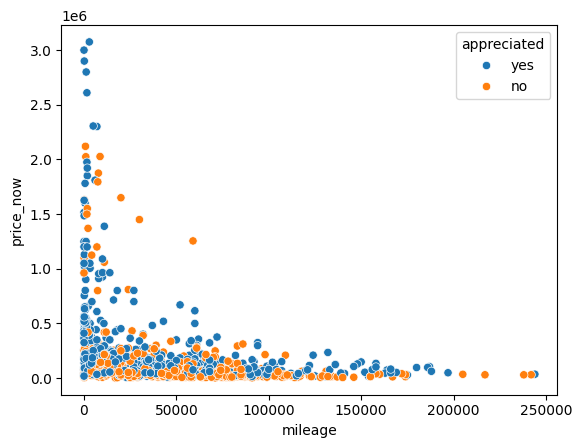

In [ ]:
# Do high mileage cars depreciate?
# Scatter plot: Mileage (x-axis) vs. Price (y-axis). Color by appreciated/depreciated
sns.scatterplot(data=df, x='mileage', y='price_now', hue='appreciated')
display(md(
    'Based on the scatter plot, high mileage cars generally appreciate.'
))

The model that has the most number of cars with apppreiated value is the **911**, produced in the year **2019**.

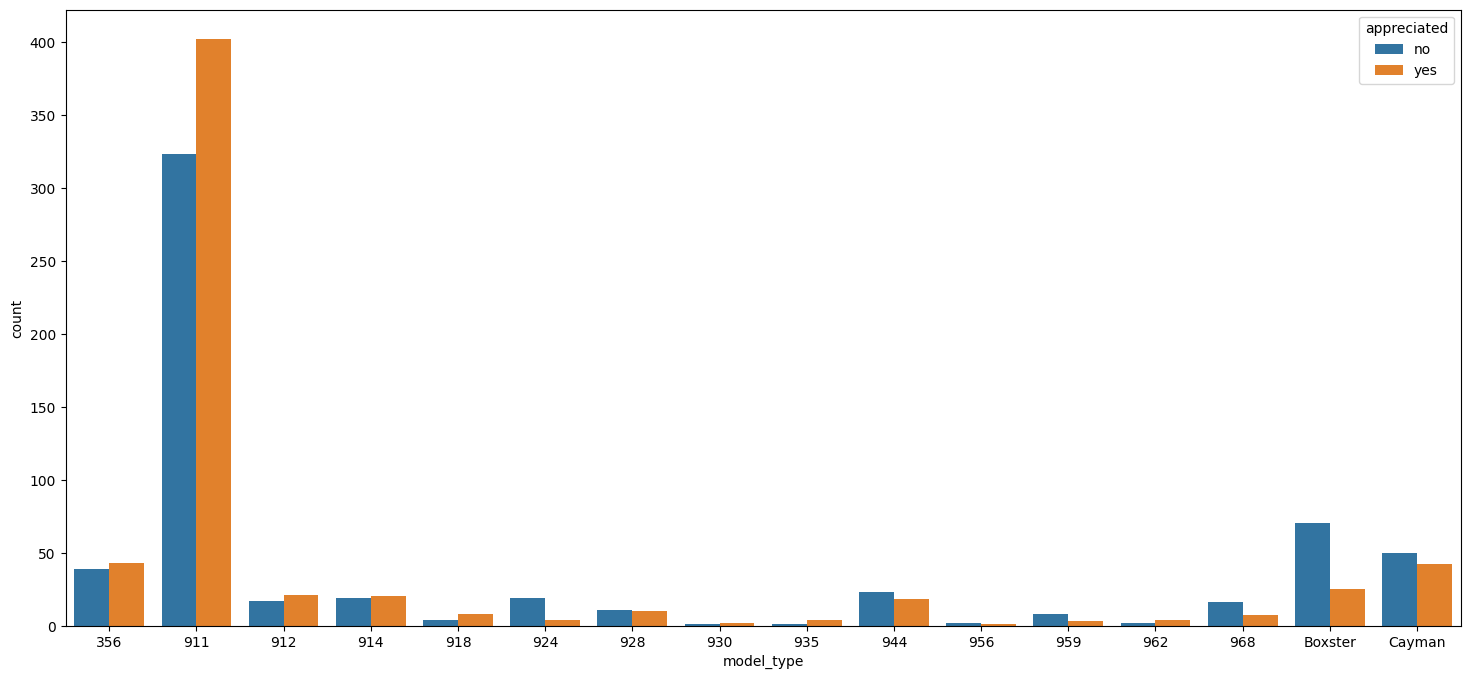

In [ ]:
# Which model appreciates the most?
# Bar chart: Count by model type (911, Cayman, Boxster)
plt.figure(figsize=(18,8))
model_type_count = df.groupby(['model_type', 'appreciated']).size().reset_index(name='count')
sns.barplot(data=model_type_count, x='model_type', y='count', hue='appreciated')

app_model = model_type_count[model_type_count['appreciated'] == 'yes'].nlargest(1, 'count')['model_type'].values[0]           # model that appreciated the most

app_model_cars = df[(df['model_type'] == app_model) & (df['appreciated'] == 'yes')]             # if model_type is equal to the top appreciated model (app_model) AND yes it's appreciated
model_year_counts = app_model_cars.groupby('model_year').size()                                 # no. of rows of app_model_cars
app_model_year = model_year_counts.idxmax()

display(md(
    f'The model that has the most number of cars with apppreiated value is the **{app_model}**, produced in the year **{round(app_model_year)}**.'
))

In [ ]:
# Are newer or older Porsches in your dataset?
# Histogram: Age distribution.

fix, ax = plt.subplots()
sns.histplot(data=df, x='model_year', kde=True)

display(md(
    'Based on the histogram, newer Porsches are in my dataset, particularly Porsches produced between the years **2015** and **2025**.'
))

NameError: name 'plt' is not defined

Based on the box plot, the "Excellent" condition commands higher prices.

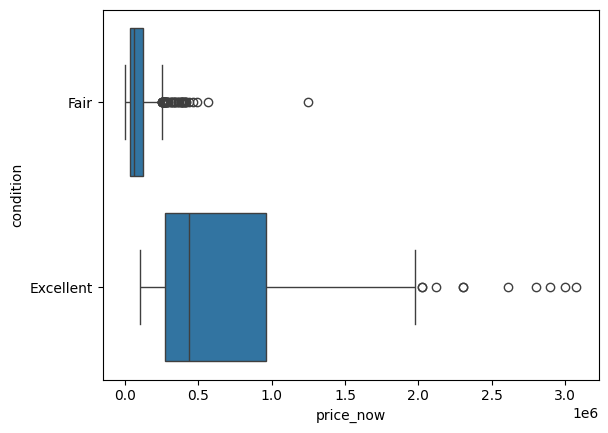

In [ ]:
# Does "Excellent" condition command higher prices?
# Box plot: Price by condition

sns.boxplot(data=df, x='price_now', y='condition')
display(md(
    'Based on the box plot, the "Excellent" condition commands higher prices.'
))

# Correlation Analysis

Based on the correlation heatmap, the listing's condition has the correlation coefficient of **0.64** (positive correlation) with the listing's price. This means that the **better** the condition of the car, the **higher** the bid/sale price.
Furthermore, the listing's condition has the correlation coefficient of **0.55** (positive correlation) with the listing's price from three years ago. This means that the **better** the condition of the car, the **higher** the bid/sale price from three years ago.

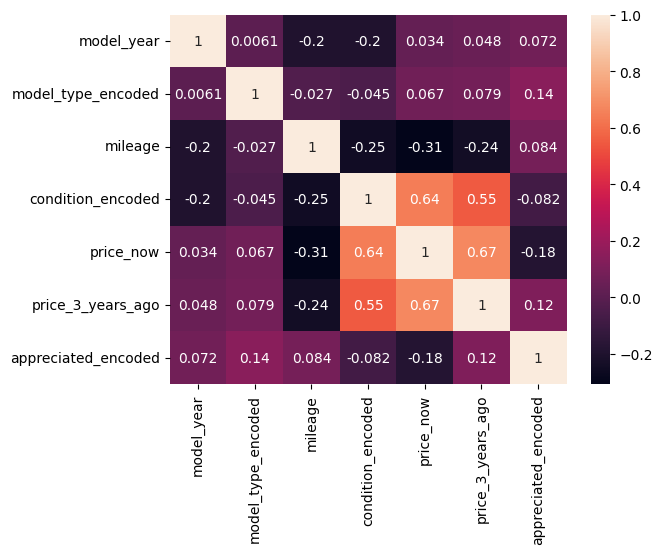

In [ ]:
# Which features correlate most strongly with appreciation?
# Encode categorical columns
df['model_type_encoded'] = pd.factorize(df['model_type'])[0]
df['condition_encoded'] = pd.factorize(df['condition'])[0]
df['appreciated_encoded'] = pd.factorize(df['appreciated'])[0]
corr_columns = ['model_year','model_type_encoded','mileage','condition_encoded','price_now','price_3_years_ago','appreciated_encoded']

# Manage 'insufficient_data' in price_3_years_ago column
corr_matrix = df[corr_columns].corr()
sns.heatmap(data=corr_matrix, annot=True)

display(md(
    f'Based on the correlation heatmap, the listing\'s condition has the correlation coefficient of **0.64** (positive correlation) with the listing\'s price. This means that the **better** the condition of the car, the **higher** the bid/sale price.\nFurthermore, the listing\'s condition has the correlation coefficient of **0.55** (positive correlation) with the listing\'s price from three years ago. This means that the **better** the condition of the car, the **higher** the bid/sale price from three years ago.'
))

# So What *Drives* A Porsche's Value Of Appreciation Over Time?

1. Condition
2. Model type
3. Mileage

**Condition** is the strongest driver of appreciation. The correlation heatmap shows condition has a 0.64 correlation with current price and 0.55 with price three years ago, indicating better condition **consistently commands** higher prices. The box plot confirms that **"Excellent" condition cars achieve the highest prices**.

**Model type** also matters: the **911** has the most appreciated listings, with certain model years showing stronger appreciation.

Interestingly, **higher mileage** cars tend to **appreciate**, suggesting rarity and collectibility can outweigh wear.

The dataset is dominated by newer Porsches (2015–2020), which may reflect market dynamics where **newer models** with **strong condition** and desirable specifications **appreciate**. Overall, **condition** is the primary factor, with **model type** (especially 911) and specific **model years** also contributing to appreciation.
